In [3]:
import os
from pathlib import Path
import joblib
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    precision_score, 
    recall_score, 
    hamming_loss,  
    multilabel_confusion_matrix,
    precision_recall_curve
)

In [4]:
# Models

MODEL ={"Random Forest": RandomForestClassifier(
    n_estimators=300,            # More trees for stable probability estimates
    class_weight='balanced',     # CRITICAL: Automatically adjusts weights inversely proportional to class frequencies
    max_depth=20,                # Deep enough to find interactions, capped to prevent overfitting spatial noise
    min_samples_split=10,        # Prevents leaf nodes from capturing outliers
    n_jobs=-1,                   # Use all CPU cores for speed
    random_state=42
),
"LightGBM": LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=8,               # Capped depth since gradient boosting builds sequentially
    num_leaves=31,             # Standard default, handles non-linear interactions well
    class_weight='balanced',   # Handles class imbalance natively inside the GBDT loss function
    subsample=0.8,             # Row masking to prevent overfitting spatial autocorrelation
    colsample_bytree=0.8,      # Feature masking per tree splitting step
    random_state=42,
    n_jobs=-1,
    verbose=-1                 # Silences unnecessary internal inner-loop tree logs
),
"MLPClassifier":MLPClassifier(
    hidden_layer_sizes=(128, 64, 32), # Deep bottleneck structure to extract spatial patterns
    activation='relu',               # Prevents vanishing gradient issues
    solver='adam',                   # Robust stochastic gradient optimizer
    alpha=0.03,                      # L2 regularization parameter to counter overfitting
    batch_size=64,                   # Stable batch sizing for sparse geographic indicators
    learning_rate_init=0.005,        # Initial step speed
    max_iter=150,                    # Epoch iteration cutoff ceiling
    early_stopping=True,             # Use internal split validation to step down early
    validation_fraction=0.1,         # Hold out 10% inside fold to check stagnation
    n_iter_no_change=10,             # Patience threshold for loss trajectory halts
    random_state=42,
    verbose=False
),
"XGBoost":XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)
}

DATA_DIR =Path(r"C:\Users\anils\Desktop\7th SEM\GIS\GeoOptim\Data\Final\MultiLabel_DATA.geojson")
MODEL_DIR =Path(r"C:\Users\anils\Desktop\7th SEM\GIS\GeoOptim\Output\Models")

In [5]:
def prepare_data(DATA_DIR):
    # ==============================================================================
    # 2. Data Loading & Feature Engineering Splits
    # ==============================================================================
    print("⏳ Loading multi-label vector dataset...")
    gdf = gpd.read_file(DATA_DIR)

    # Isolate dynamic feature arrays and binary label categories
    target_cols = [col for col in gdf.columns if col.startswith('is_')]
    metadata_cols = ['h3_id', 'geometry'] + target_cols
    feature_cols = [col for col in gdf.columns if col not in metadata_cols]
    clean_label_names = [col.replace('is_', '') for col in target_cols]

    X = gdf[feature_cols].copy()
    y = gdf[target_cols].copy()

    # Execute random train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # ==============================================================================
    # 3. Scale and Normalize Context Matrices
    # ==============================================================================
    print("⚖️ Fitting RobustScaler transform matrices...")
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    scaler_out_path = MODEL_DIR / f"{DATA_DIR.name.split(".")[0]}"
    scaler_out_path.mkdir(parents=True, exist_ok=True)
    joblib.dump(scaler, scaler_out_path/"robust_scaler.pkl")
    print(f"✅ Scaler object saved to: {scaler_out_path}")

    return X_train_scaled, X_test_scaled, y_train, y_test, clean_label_names, feature_cols

In [9]:
def plot_feature_importance_per_class(
    model,
    feature_names,
    class_names,
    model_name,
    top_n=20,
    figsize=(10, 6)
):
    """
    Plot feature importance for each label in a MultiOutputClassifier.

    Parameters
    ----------
    model : MultiOutputClassifier
        Trained MultiOutputClassifier.
    feature_names : list
        Names of the input features.
    class_names : list
        Names of the output labels.
    model_name : str
        Model name for plot titles.
    top_n : int
        Number of top features to display.
    figsize : tuple
        Figure size.
    """

    if not hasattr(model, "estimators_"):
        raise ValueError("Model must be a fitted MultiOutputClassifier.")

    for label_name, estimator in zip(class_names, model.estimators_):

        if not hasattr(estimator, "feature_importances_"):
            print(f"{model_name} - {label_name}: Feature importance not available.")
            continue

        importance_df = (
            pd.DataFrame({
                "Feature": feature_names,
                "Importance": estimator.feature_importances_
            })
            .sort_values("Importance", ascending=False)
            .head(top_n)
        )

        plt.figure(figsize=figsize)

        plt.barh(
            importance_df["Feature"][::-1],
            importance_df["Importance"][::-1]
        )

        plt.xlabel("Feature Importance")
        plt.ylabel("Feature")
        plt.title(f"{model_name} - {label_name}")
        plt.tight_layout()
        plt.show()

In [10]:
def train_model(DATA_DIR, MODEL):
    x_train, x_test, y_train, y_test, columns , features = prepare_data(DATA_DIR)
    for mname, model in MODEL.items():
        print(f"🚀 Training {mname} Multi-Label Architecture...")
        if mname !="MLPClassifier":
            model = MultiOutputClassifier(model, n_jobs=-1)
            model.fit(x_train, y_train)
            plot_feature_importance_per_class(
                        model=model,
                        feature_names=features,
                        class_names=columns,
                        model_name=mname,
                        top_n=20
                    )
        else:
            model.fit(x_train, y_train)
        

        best_thresholds, y_pred = threshold_optimization(model, x_test, mname, y_test, columns)
        plot_metrics(y_test, y_pred, columns, mname)


# ==============================================================================
# Diagnostic Evaluations & Metrics Engine
# ==============================================================================
def plot_metrics(y_true, y_pred, classes, mname):
    """
    Computes global metrics and isolates individual class performance arrays 
    for detailed visual mapping over validation datasets.
    """
    print("\n" + "="*60)
    print(f"📊 GLOBAL MULTI-LABEL PERFORMANCE METRICS {mname}")
    print("="*60)
    print(f"Overall Exact Match Ratio (Subset Accuracy): {accuracy_score(y_true, y_pred):.4f}")
    print(f"Macro F1-Score Baseline:                     {f1_score(y_true, y_pred, average='macro'):.4f}")
    print(f"Global Hamming Loss Threshold:              {hamming_loss(y_true, y_pred):.4f}")
    print("-"*60)

    y_true_arr = np.array(y_true)
    y_pred_arr = np.array(y_pred)
    
    class_metrics = []
    for idx, class_name in enumerate(classes):
        c_true = y_true_arr[:, idx]
        c_pred = y_pred_arr[:, idx]
        
        class_metrics.append({
            "Commercial Class": class_name,
            "Accuracy": accuracy_score(c_true, c_pred),
            "F1-Score": f1_score(c_true, c_pred, zero_division=0),
            "Precision": precision_score(c_true, c_pred, zero_division=0),
            "Recall": recall_score(c_true, c_pred, zero_division=0)
        })
    
    metrics_df = pd.DataFrame(class_metrics).set_index("Commercial Class")
    print("\n🔍 CLASS-WISE VALIDATION EVALUATIONS:")
    print(metrics_df.round(4).to_string())
    print("\n" + "="*60)

    # Generate Confusion Matrix Matrices
    mcm = multilabel_confusion_matrix(y_true, y_pred)
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.ravel()

    for i in range(len(classes)):
        cm_sum = mcm[i].sum(axis=1)[:, np.newaxis]
        cm_normalized = np.divide(mcm[i].astype('float'), cm_sum, out=np.zeros_like(mcm[i], dtype=float), where=cm_sum!=0)
        
        labels = np.asarray([
            f"{v}\n({p:.1%})" for v, p in zip(mcm[i].flatten(), cm_normalized.flatten())
        ]).reshape(2, 2)
        
        sns.heatmap(
            mcm[i], annot=labels, fmt="", cmap='Blues', cbar=False, ax=axes[i],
            xticklabels=['Predicted Absent', 'Predicted Present'],
            yticklabels=['Actual Absent', 'Actual Present']
        )
        axes[i].set_title(f'{classes[i]}', fontsize=12, fontweight='bold')
        axes[i].set_ylabel('Ground Truth')
        axes[i].set_xlabel('Model Predictions')

    for j in range(len(classes), len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle('Class-Wise Validation Confusion Matrices', fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()


def threshold_optimization(model, X_test, mname, y_test, columns):
    # ==============================================================================
    # Dynamic Threshold Optimization & Prediction
    # ==============================================================================
    print("🎯 Calculating optimal decision thresholds per class...")
    # predict_proba in multi-label RF returns a list of arrays (one for each class).
    # We extract the probability of the positive class (index 1) for each label.
    y_prob_list = model.predict_proba(X_test)
    if mname =="MLPClassifier":
        y_prob = y_prob_list
    else:
        y_prob = np.column_stack([prob[:, 1] for prob in y_prob_list])

    y_pred_optimal = np.zeros_like(y_prob)
    best_thresholds = []

    # Find the threshold that maximizes the F1-Score for EACH class independently
    for i in range(y_prob.shape[1]):
        precision, recall, thresholds = precision_recall_curve(y_test.iloc[:, i], y_prob[:, i])
        
        # Calculate F1 scores across all possible thresholds, avoiding division by zero
        f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
        best_idx = np.argmax(f1_scores)
        
        # Handle edge case where threshold array is slightly shorter than precision/recall arrays
        best_thresh = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
        best_thresholds.append(best_thresh)
        
        # Apply this specific threshold to generate final predictions
        y_pred_optimal[:, i] = (y_prob[:, i] >= best_thresh).astype(int)

    print("\nOptimal Thresholds for Heatmaps:")
    for name, thresh in zip(columns, best_thresholds):
        print(f" - {name}: {thresh:.3f}")

    return best_thresholds, y_pred_optimal


⏳ Loading multi-label vector dataset...
⚖️ Fitting RobustScaler transform matrices...
✅ Scaler object saved to: C:\Users\anils\Desktop\7th SEM\GIS\GeoOptim\Output\Models\MultiLabel_DATA
🚀 Training Random Forest Multi-Label Architecture...


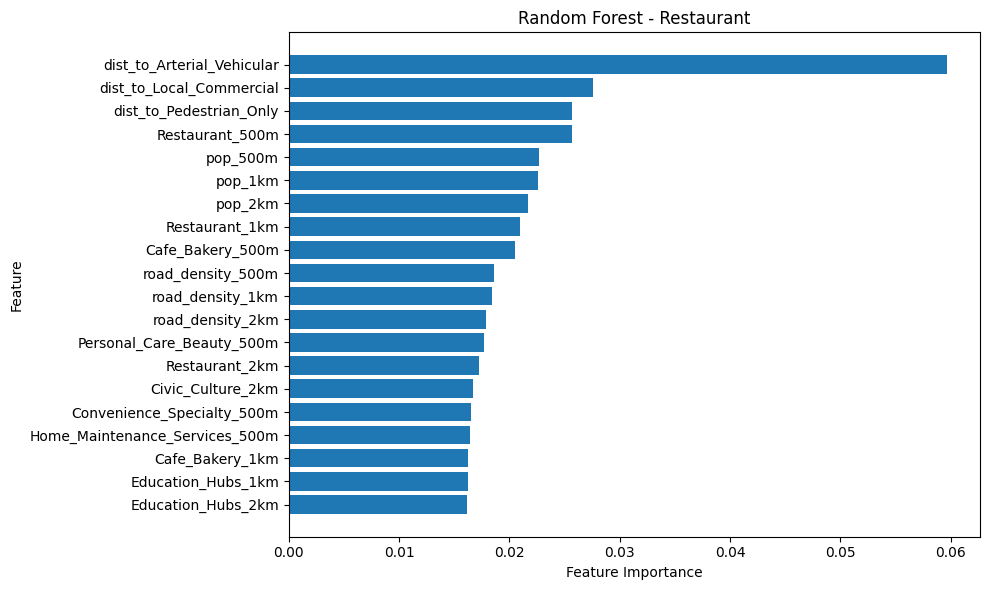

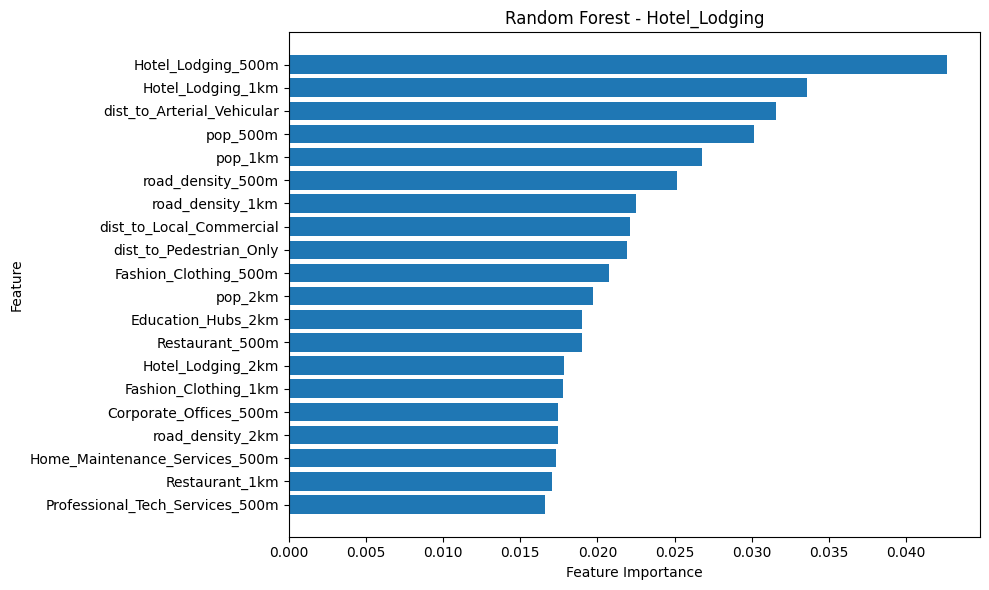

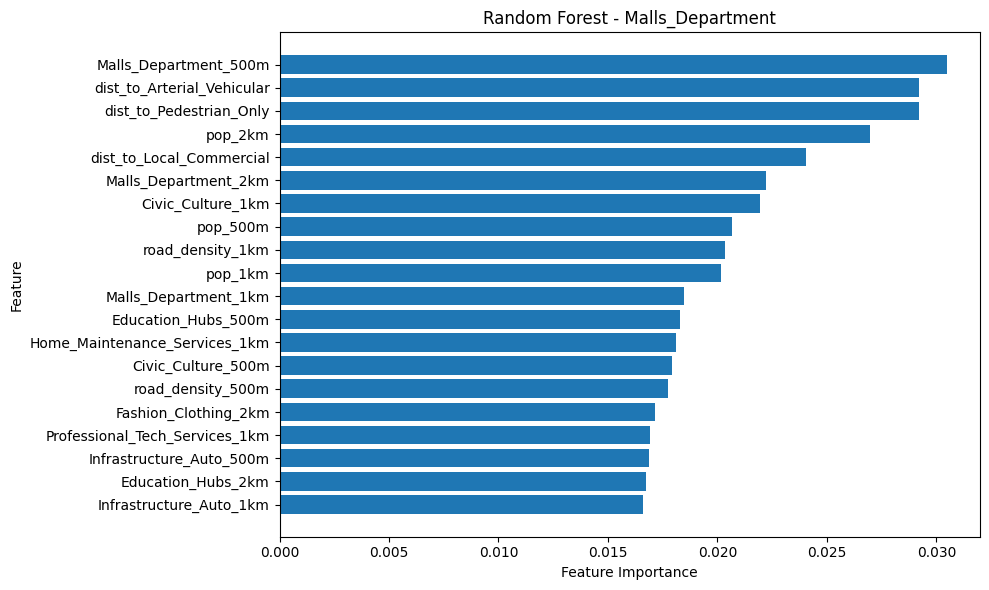

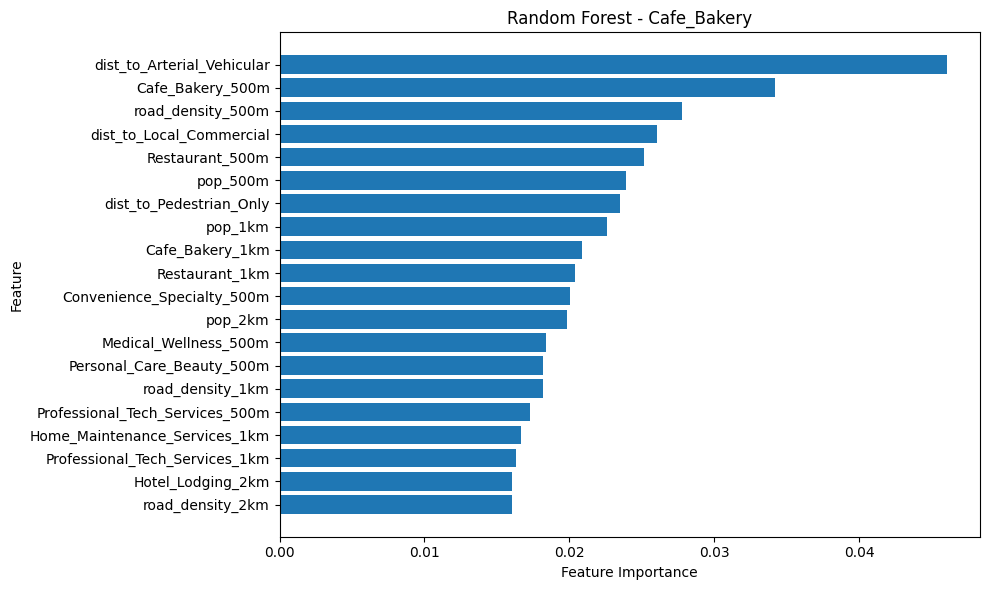

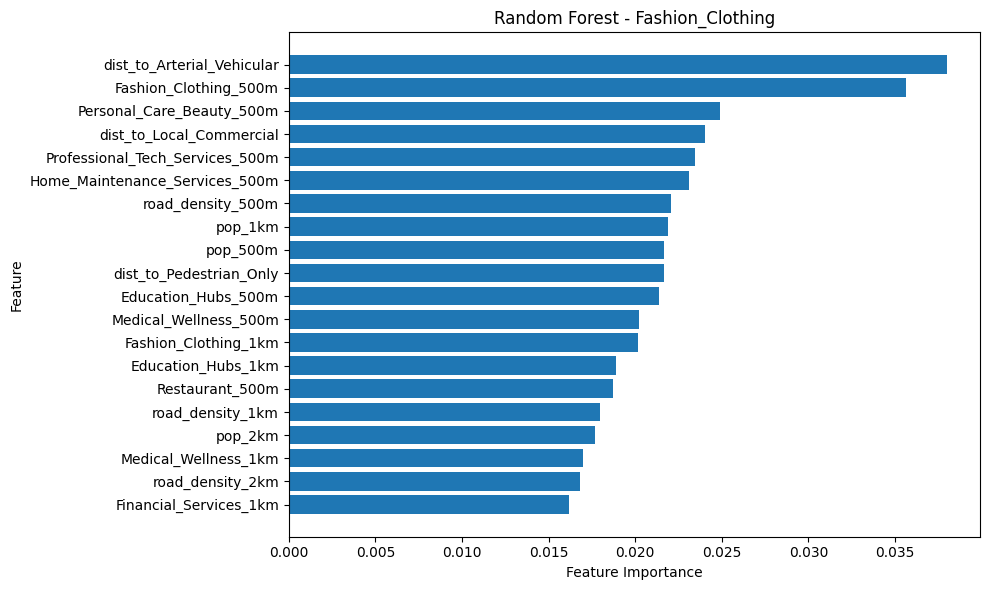

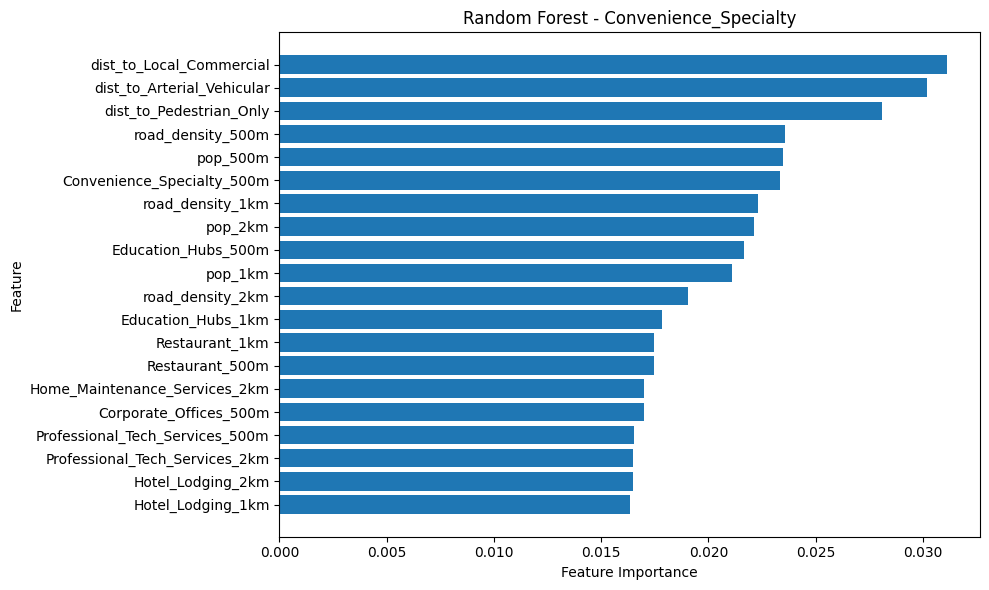

🎯 Calculating optimal decision thresholds per class...

Optimal Thresholds for Heatmaps:
 - Restaurant: 0.245
 - Hotel_Lodging: 0.377
 - Malls_Department: 0.212
 - Cafe_Bakery: 0.396
 - Fashion_Clothing: 0.354
 - Convenience_Specialty: 0.243

📊 GLOBAL MULTI-LABEL PERFORMANCE METRICS Random Forest
Overall Exact Match Ratio (Subset Accuracy): 0.0873
Macro F1-Score Baseline:                     0.4977
Global Hamming Loss Threshold:              0.3547
------------------------------------------------------------

🔍 CLASS-WISE VALIDATION EVALUATIONS:
                       Accuracy  F1-Score  Precision  Recall
Commercial Class                                            
Restaurant               0.5459    0.6880     0.5317  0.9745
Hotel_Lodging            0.6346    0.6047     0.5189  0.7245
Malls_Department         0.7962    0.2135     0.1508  0.3654
Cafe_Bakery              0.6754    0.4966     0.4400  0.5699
Fashion_Clothing         0.6885    0.5466     0.4725  0.6482
Convenience_Specialty

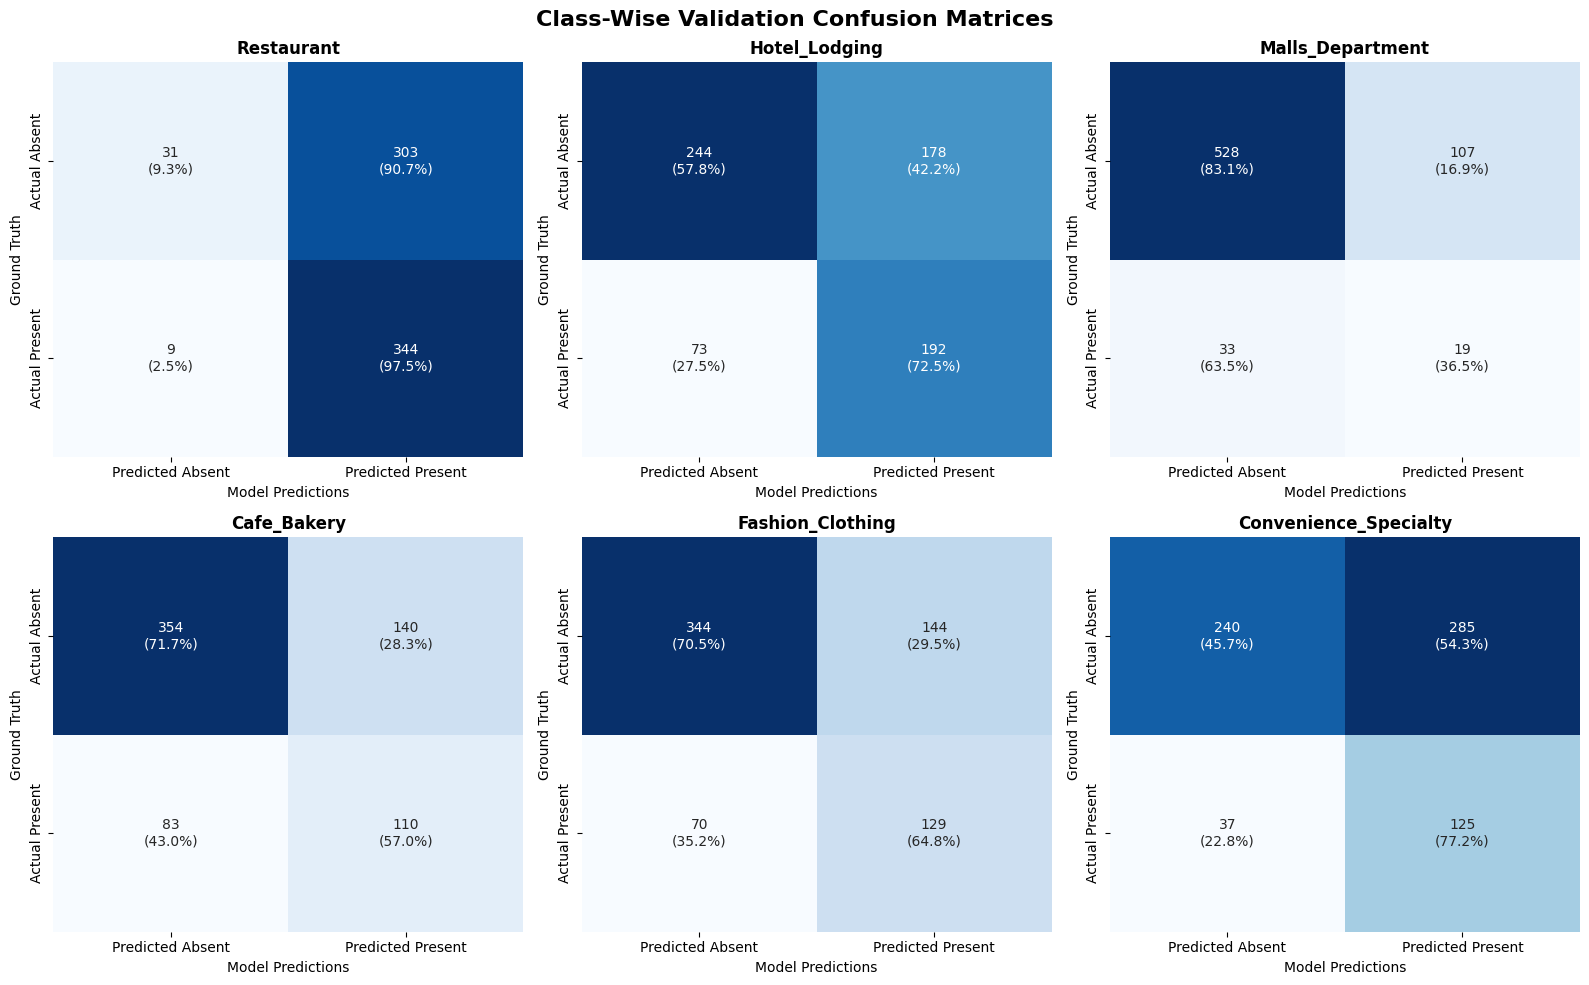

🚀 Training LightGBM Multi-Label Architecture...


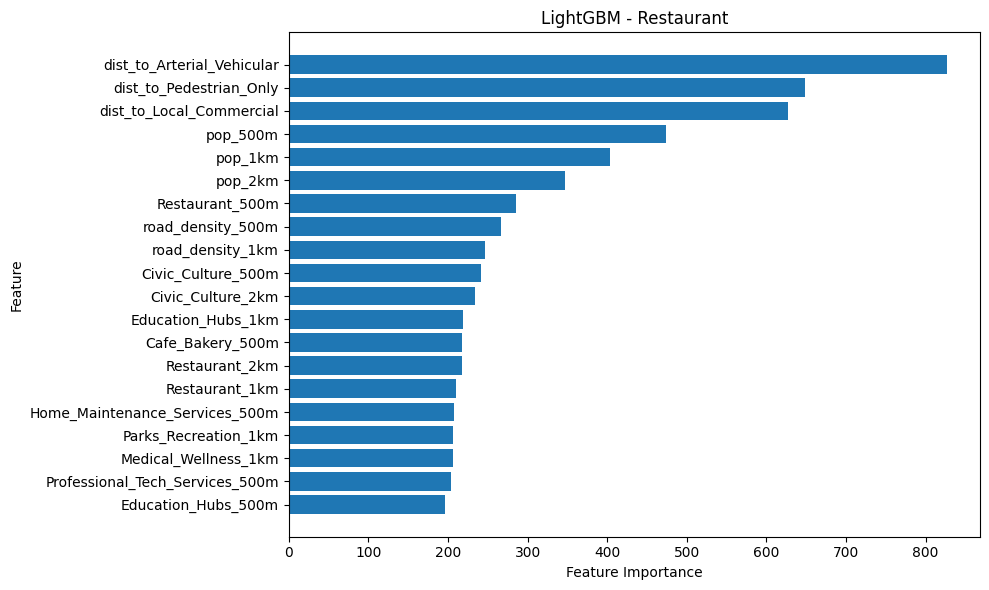

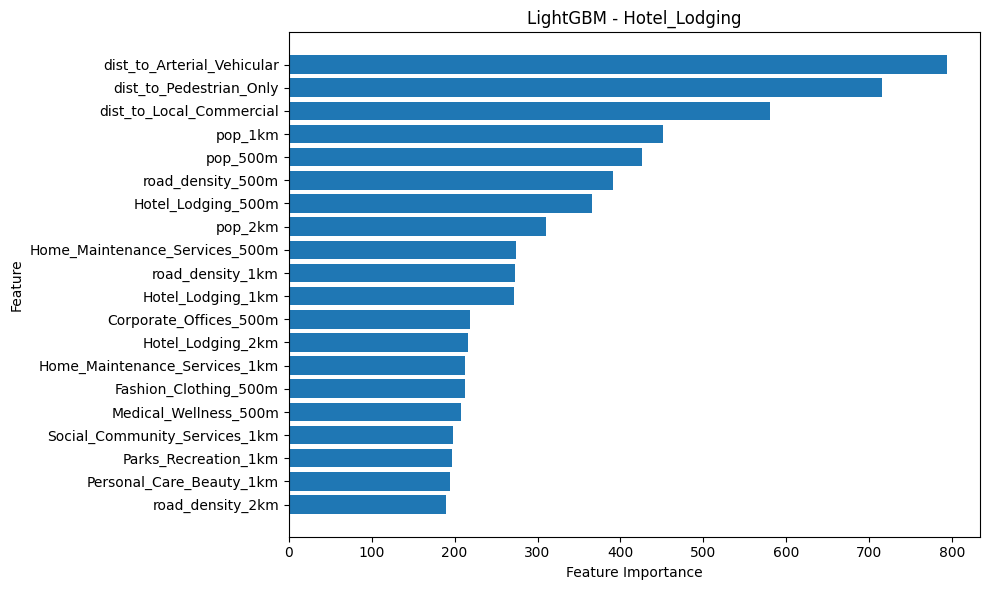

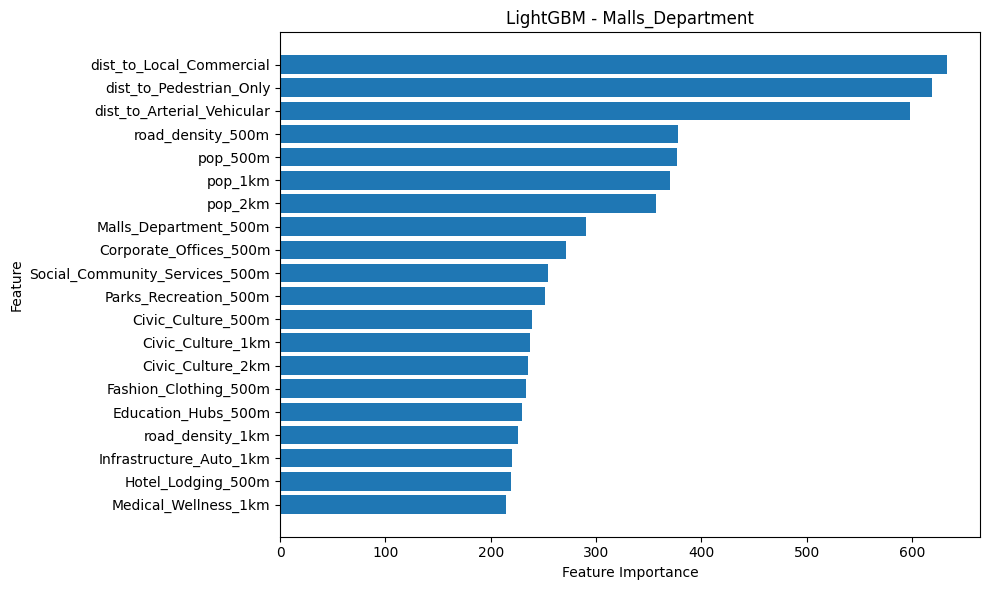

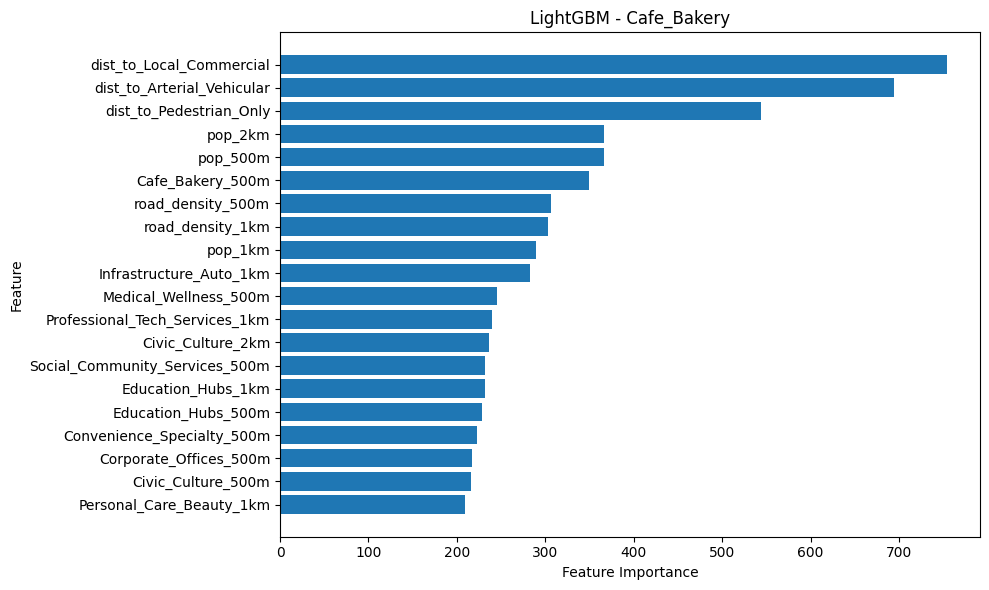

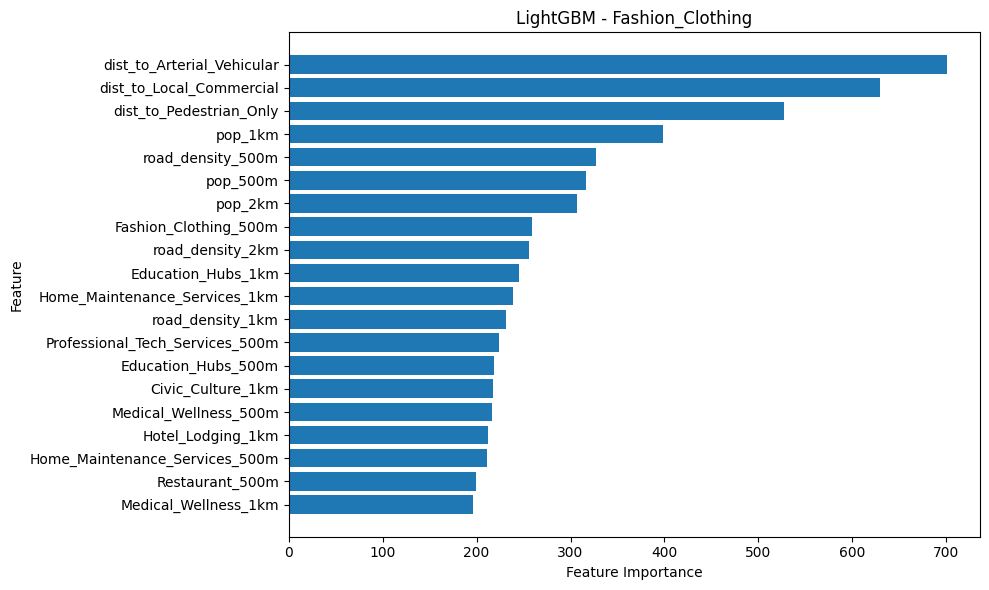

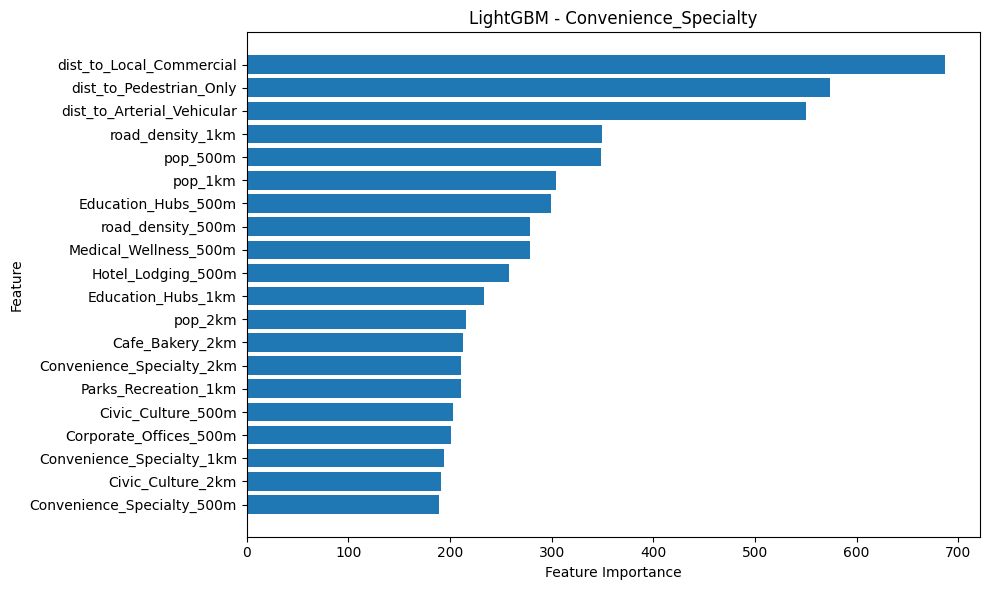

🎯 Calculating optimal decision thresholds per class...

Optimal Thresholds for Heatmaps:
 - Restaurant: 0.175
 - Hotel_Lodging: 0.246
 - Malls_Department: 0.204
 - Cafe_Bakery: 0.213
 - Fashion_Clothing: 0.369
 - Convenience_Specialty: 0.293

📊 GLOBAL MULTI-LABEL PERFORMANCE METRICS LightGBM
Overall Exact Match Ratio (Subset Accuracy): 0.0568
Macro F1-Score Baseline:                     0.4887
Global Hamming Loss Threshold:              0.3809
------------------------------------------------------------

🔍 CLASS-WISE VALIDATION EVALUATIONS:
                       Accuracy  F1-Score  Precision  Recall
Commercial Class                                            
Restaurant               0.5429    0.6809     0.5309  0.9490
Hotel_Lodging            0.5750    0.6054     0.4716  0.8453
Malls_Department         0.8137    0.2195     0.1607  0.3462
Cafe_Bakery              0.5400    0.4952     0.3580  0.8031
Fashion_Clothing         0.6594    0.5125     0.4377  0.6181
Convenience_Specialty    0

c:\Users\anils\Desktop\7th SEM\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\anils\Desktop\7th SEM\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\anils\Desktop\7th SEM\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\anils\Desktop\7th SEM\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\anils\Desktop\7th SEM\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  

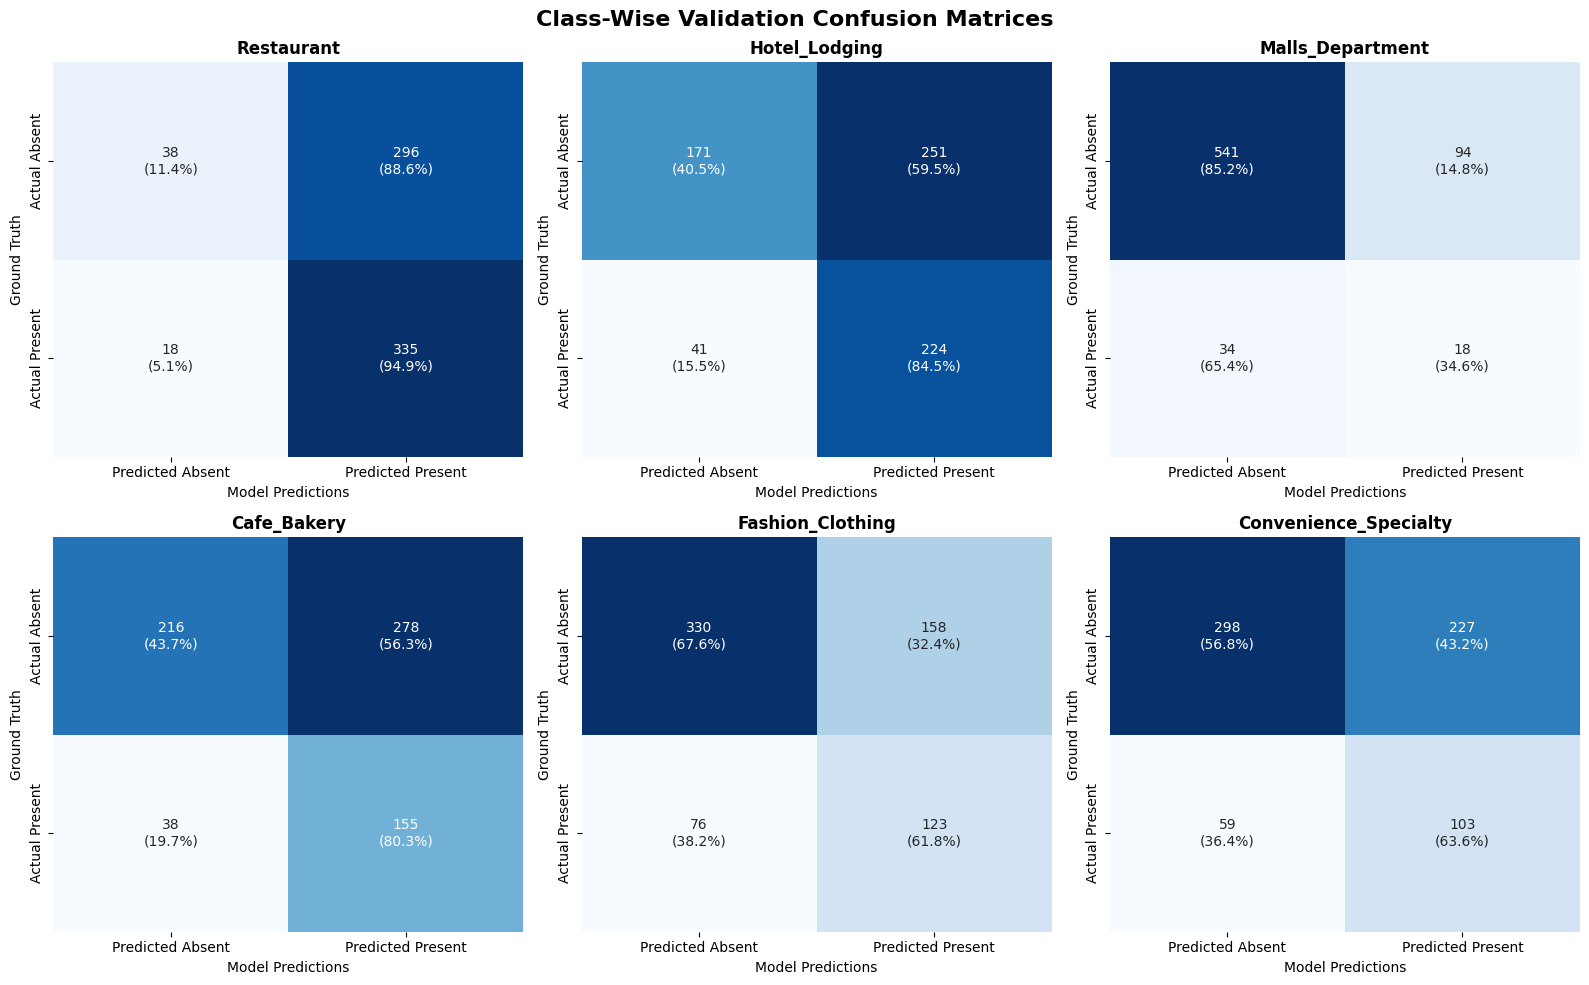

🚀 Training MLPClassifier Multi-Label Architecture...
🎯 Calculating optimal decision thresholds per class...

Optimal Thresholds for Heatmaps:
 - Restaurant: 0.011
 - Hotel_Lodging: 0.227
 - Malls_Department: 0.234
 - Cafe_Bakery: 0.276
 - Fashion_Clothing: 0.224
 - Convenience_Specialty: 0.172

📊 GLOBAL MULTI-LABEL PERFORMANCE METRICS MLPClassifier
Overall Exact Match Ratio (Subset Accuracy): 0.0553
Macro F1-Score Baseline:                     0.4969
Global Hamming Loss Threshold:              0.3734
------------------------------------------------------------

🔍 CLASS-WISE VALIDATION EVALUATIONS:
                       Accuracy  F1-Score  Precision  Recall
Commercial Class                                            
Restaurant               0.5138    0.6788     0.5138  1.0000
Hotel_Lodging            0.5648    0.6092     0.4660  0.8792
Malls_Department         0.8894    0.2245     0.2391  0.2115
Cafe_Bakery              0.6754    0.5225     0.4453  0.6321
Fashion_Clothing         0.62

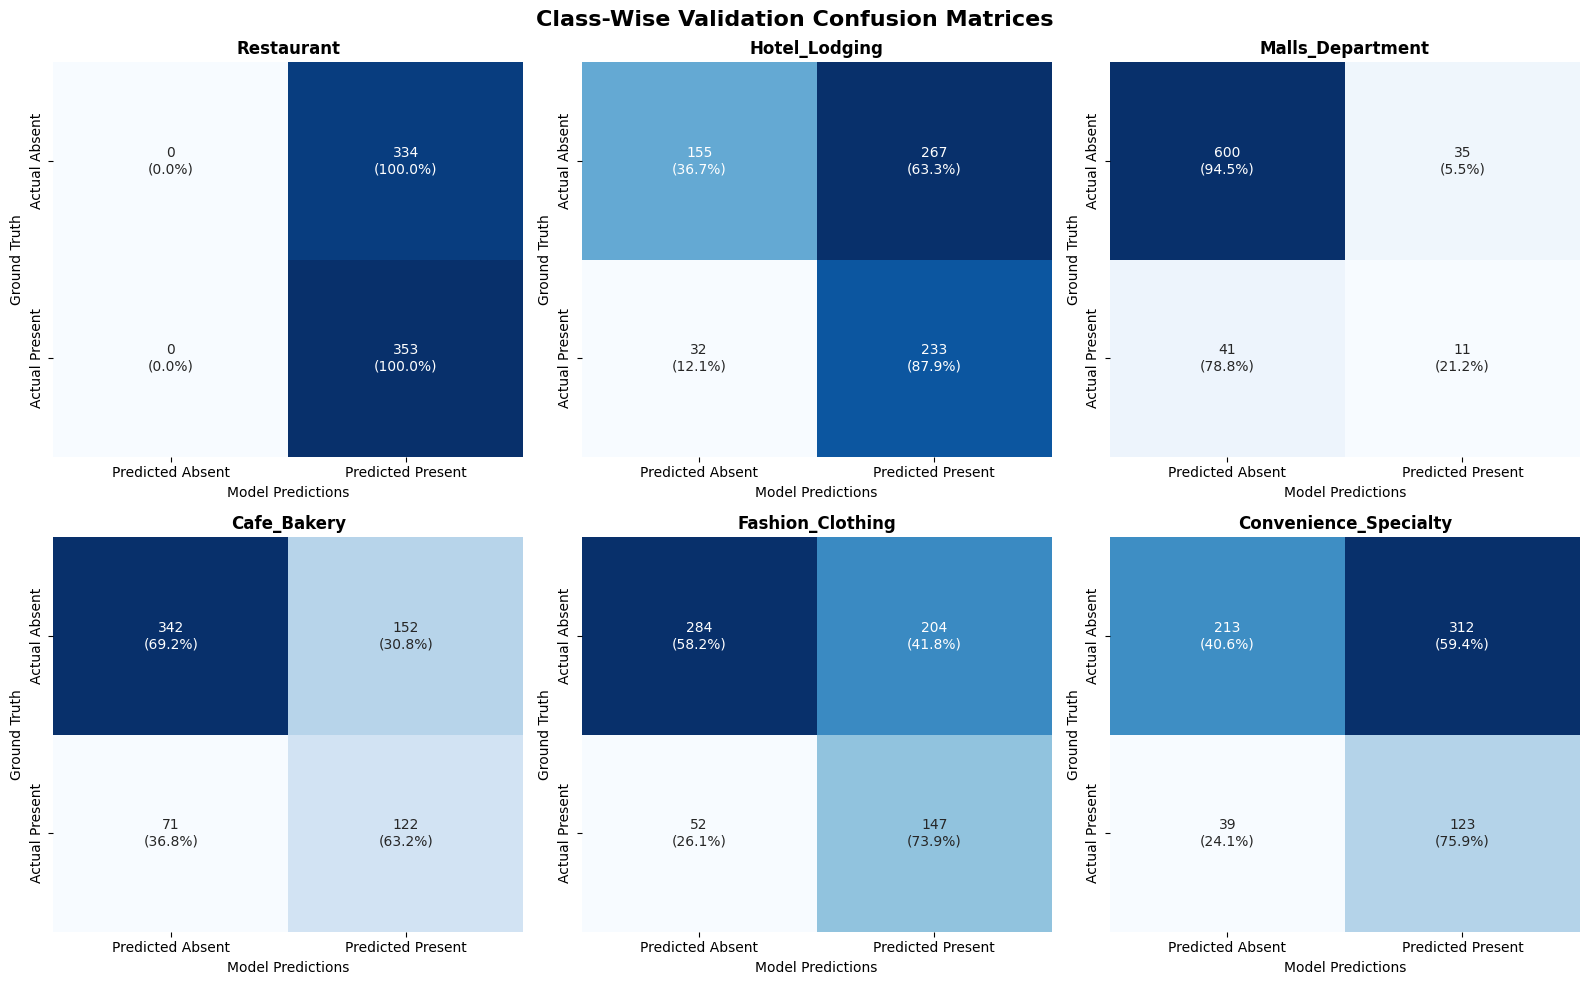

🚀 Training XGBoost Multi-Label Architecture...


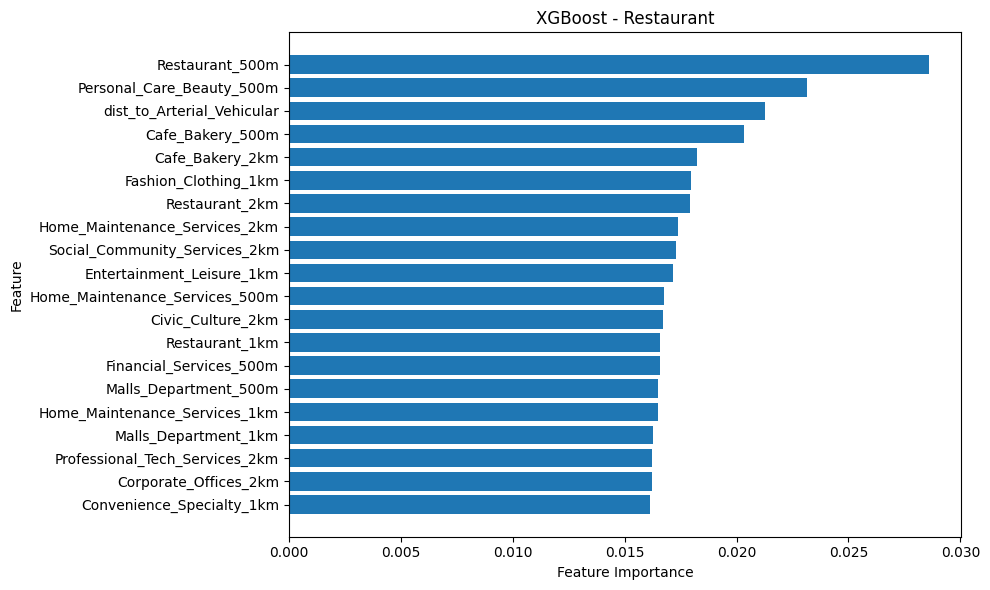

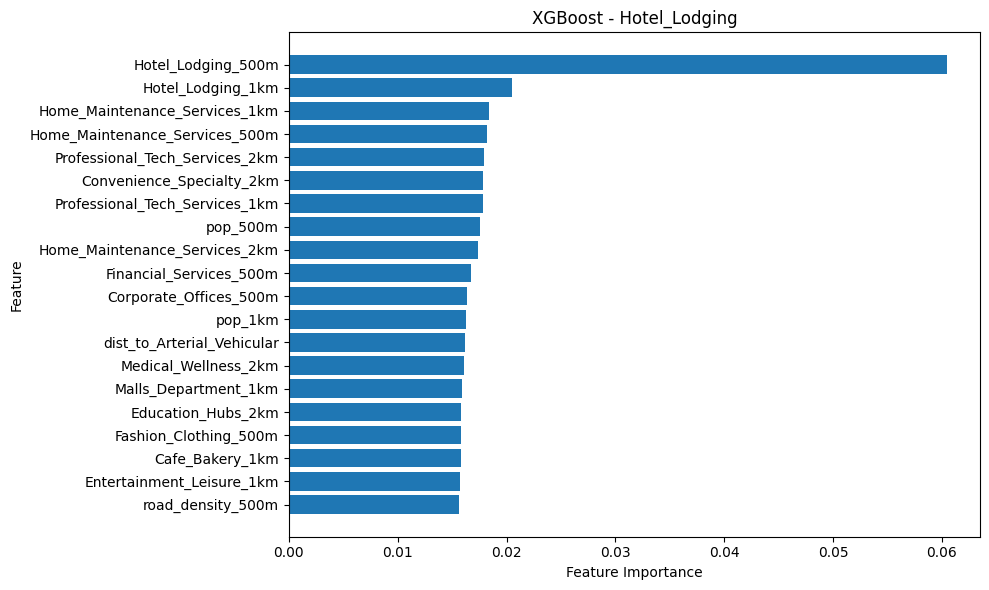

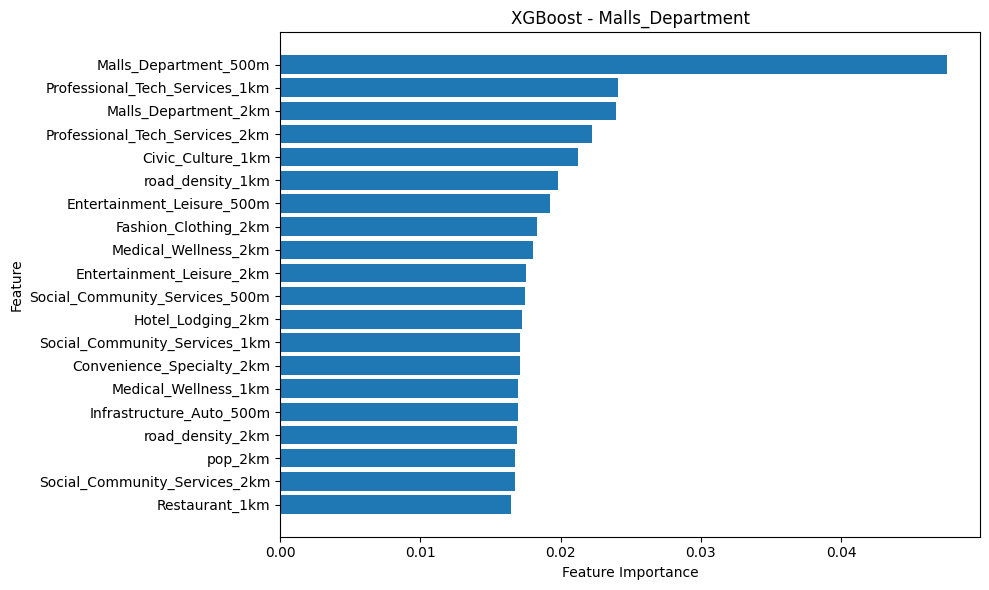

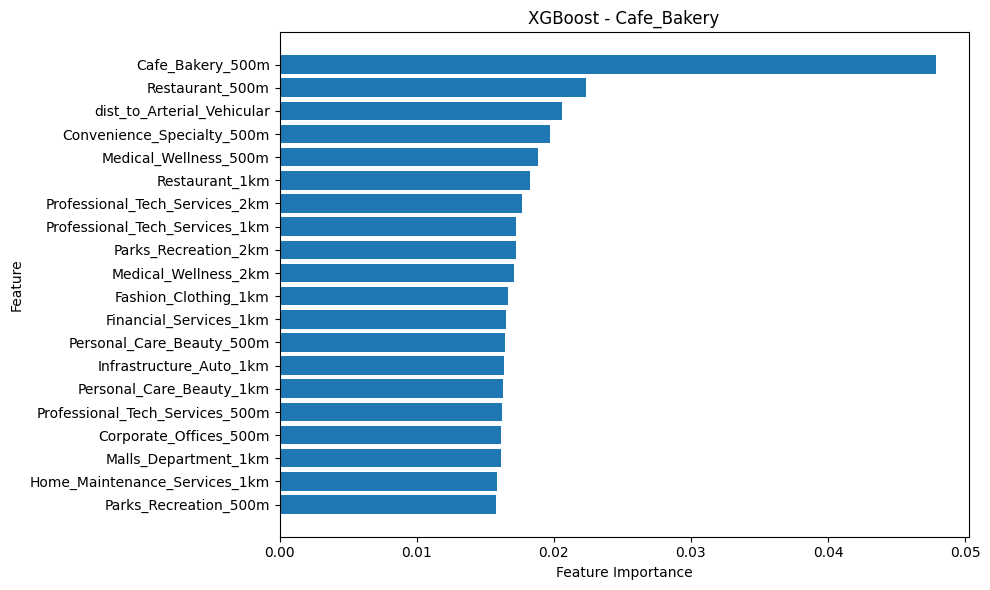

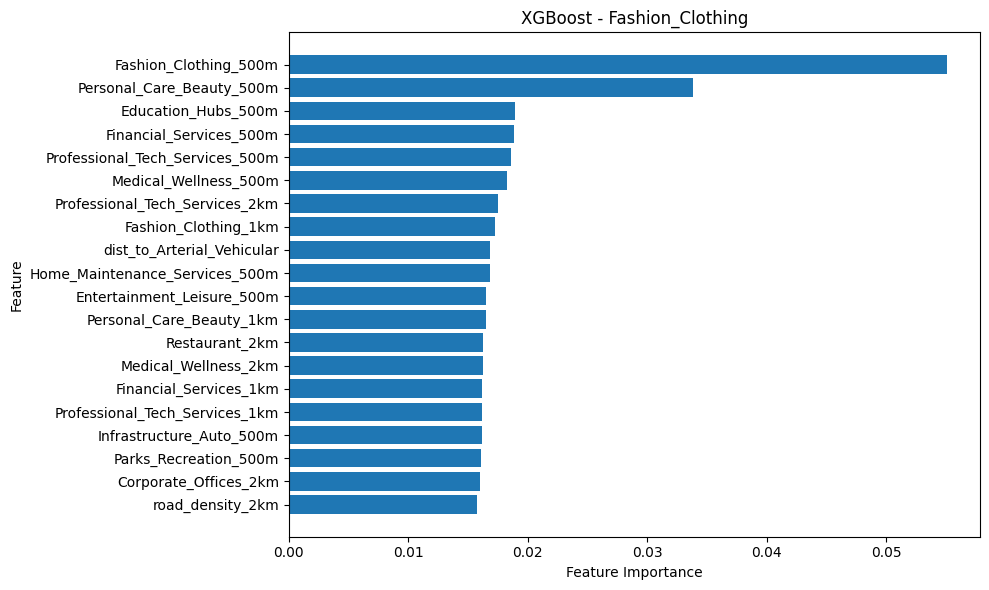

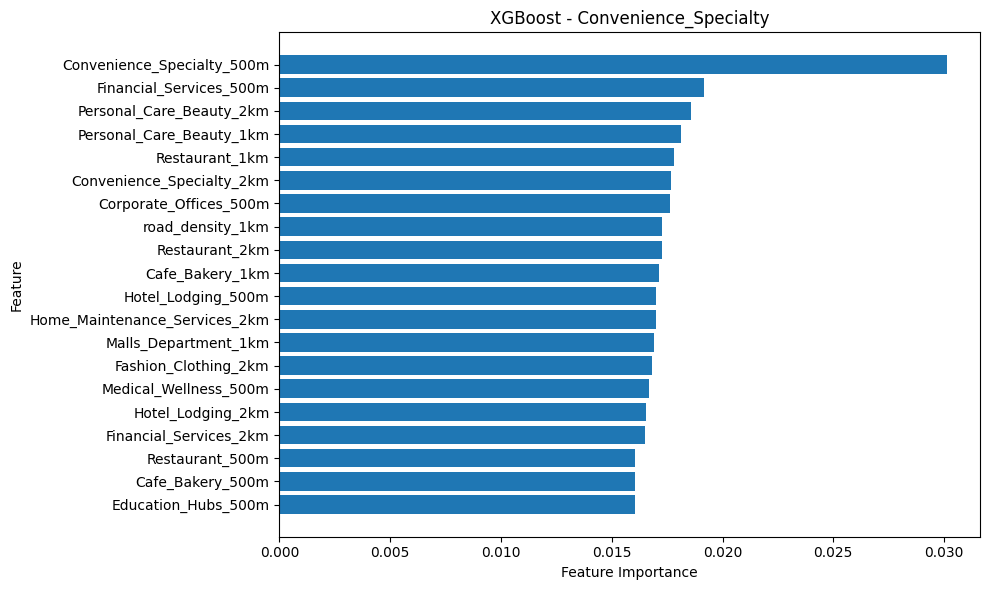

🎯 Calculating optimal decision thresholds per class...

Optimal Thresholds for Heatmaps:
 - Restaurant: 0.119
 - Hotel_Lodging: 0.110
 - Malls_Department: 0.133
 - Cafe_Bakery: 0.102
 - Fashion_Clothing: 0.149
 - Convenience_Specialty: 0.094

📊 GLOBAL MULTI-LABEL PERFORMANCE METRICS XGBoost
Overall Exact Match Ratio (Subset Accuracy): 0.0509
Macro F1-Score Baseline:                     0.4957
Global Hamming Loss Threshold:              0.3777
------------------------------------------------------------

🔍 CLASS-WISE VALIDATION EVALUATIONS:
                       Accuracy  F1-Score  Precision  Recall
Commercial Class                                            
Restaurant               0.5502    0.6857     0.5349  0.9547
Hotel_Lodging            0.5590    0.6090     0.4627  0.8906
Malls_Department         0.8806    0.2407     0.2321  0.2500
Cafe_Bakery              0.5415    0.4928     0.3575  0.7927
Fashion_Clothing         0.6361    0.5211     0.4211  0.6834
Convenience_Specialty    0.

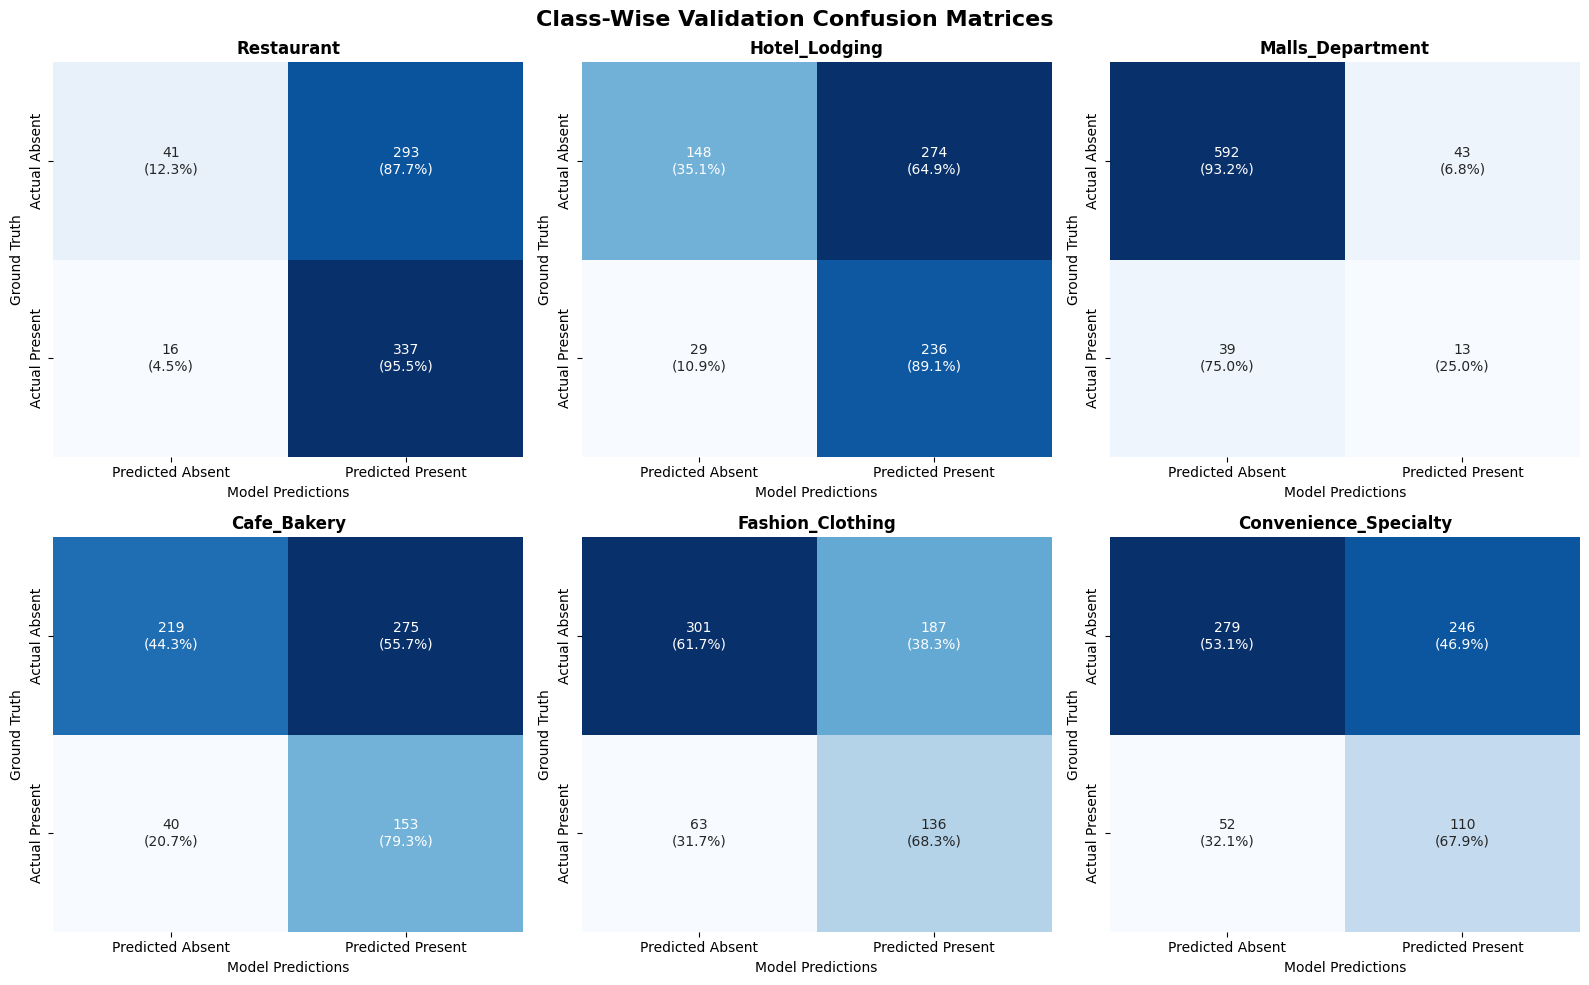

In [11]:
train_model(DATA_DIR, MODEL)

⏳ Loading multi-label vector dataset...
⚖️ Fitting RobustScaler transform matrices...
✅ Scaler object saved to: C:\Users\anils\Desktop\7th SEM\GIS\GeoOptim\Output\Models\MultiLabel_DATA_V2
🚀 Training Random Forest Multi-Label Architecture...
🎯 Calculating optimal decision thresholds per class...

Optimal Thresholds for Heatmaps:
 - Restaurant: 0.254
 - Hotel_Lodging: 0.317
 - Malls_Department: 0.355
 - Cafe_Bakery: 0.375
 - Fashion_Clothing: 0.387
 - Convenience_Specialty: 0.340

📊 GLOBAL MULTI-LABEL PERFORMANCE METRICS Random Forest
Overall Exact Match Ratio (Subset Accuracy): 0.1121
Macro F1-Score Baseline:                     0.5046
Global Hamming Loss Threshold:              0.3586
------------------------------------------------------------

🔍 CLASS-WISE VALIDATION EVALUATIONS:
                       Accuracy  F1-Score  Precision  Recall
Commercial Class                                            
Restaurant               0.5502    0.6888     0.5344  0.9688
Hotel_Lodging          

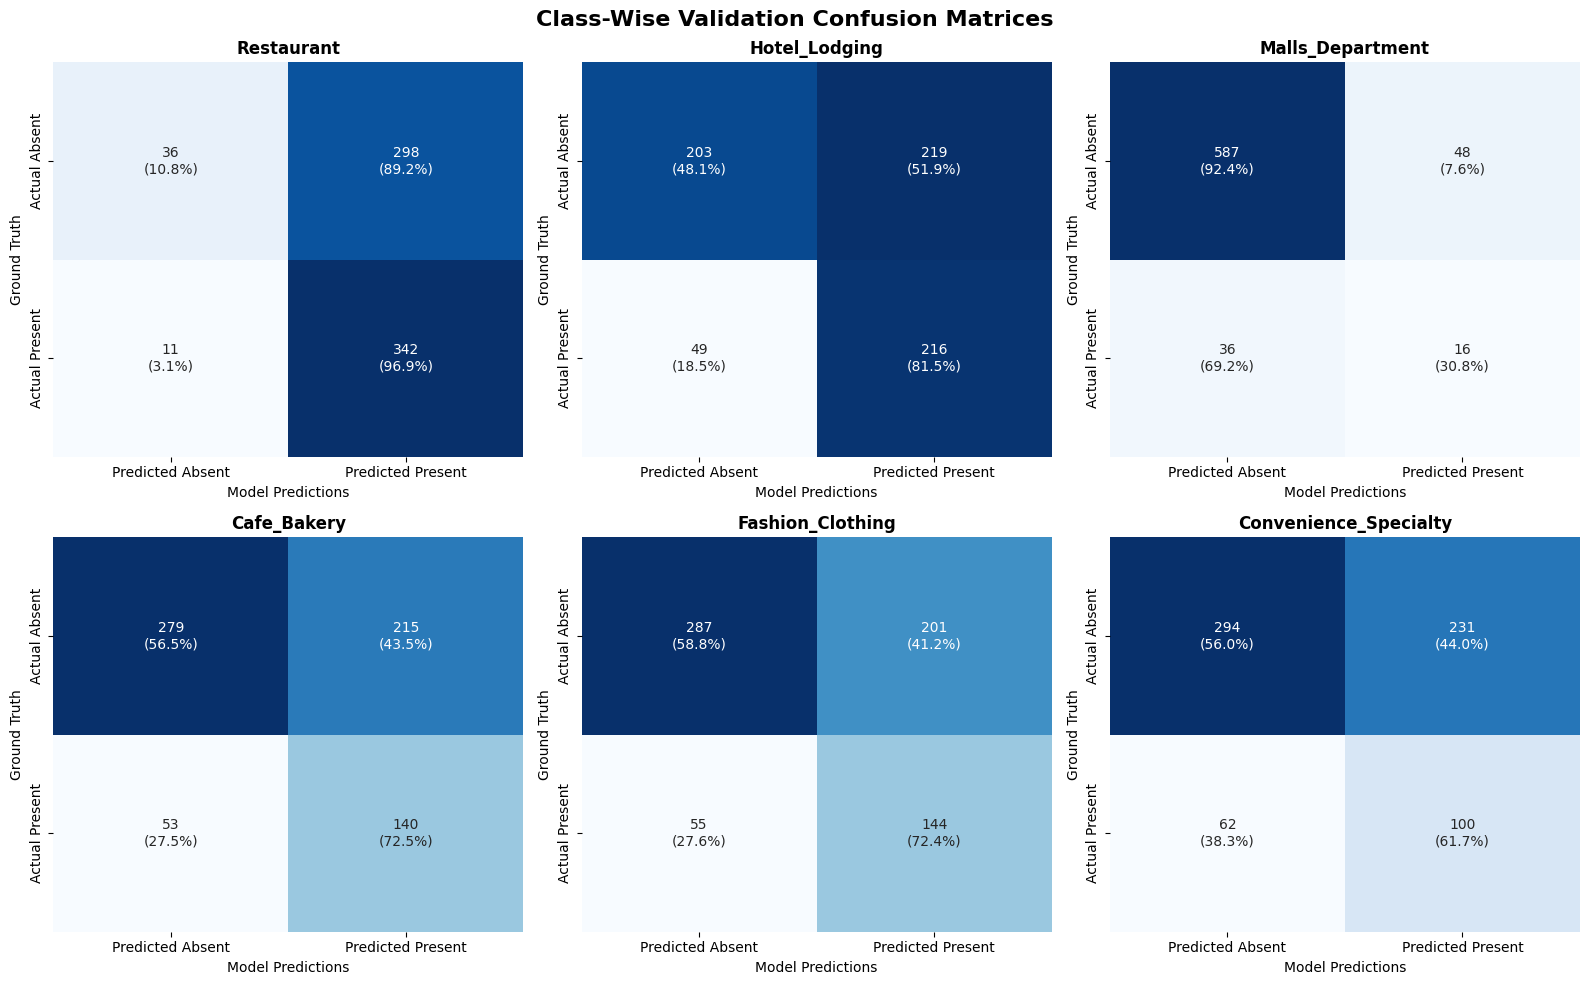

🚀 Training LightGBM Multi-Label Architecture...
🎯 Calculating optimal decision thresholds per class...

Optimal Thresholds for Heatmaps:
 - Restaurant: 0.206
 - Hotel_Lodging: 0.261
 - Malls_Department: 0.365
 - Cafe_Bakery: 0.255
 - Fashion_Clothing: 0.272
 - Convenience_Specialty: 0.068

📊 GLOBAL MULTI-LABEL PERFORMANCE METRICS LightGBM
Overall Exact Match Ratio (Subset Accuracy): 0.0349
Macro F1-Score Baseline:                     0.4837
Global Hamming Loss Threshold:              0.4110
------------------------------------------------------------

🔍 CLASS-WISE VALIDATION EVALUATIONS:
                       Accuracy  F1-Score  Precision  Recall
Commercial Class                                            
Restaurant               0.5604    0.6808     0.5430  0.9122
Hotel_Lodging            0.5968    0.6049     0.4862  0.8000
Malls_Department         0.8923    0.2292     0.2500  0.2115
Cafe_Bakery              0.5633    0.4863     0.3632  0.7358
Fashion_Clothing         0.6055    0.50

c:\Users\anils\Desktop\7th SEM\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\anils\Desktop\7th SEM\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\anils\Desktop\7th SEM\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\anils\Desktop\7th SEM\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\anils\Desktop\7th SEM\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  

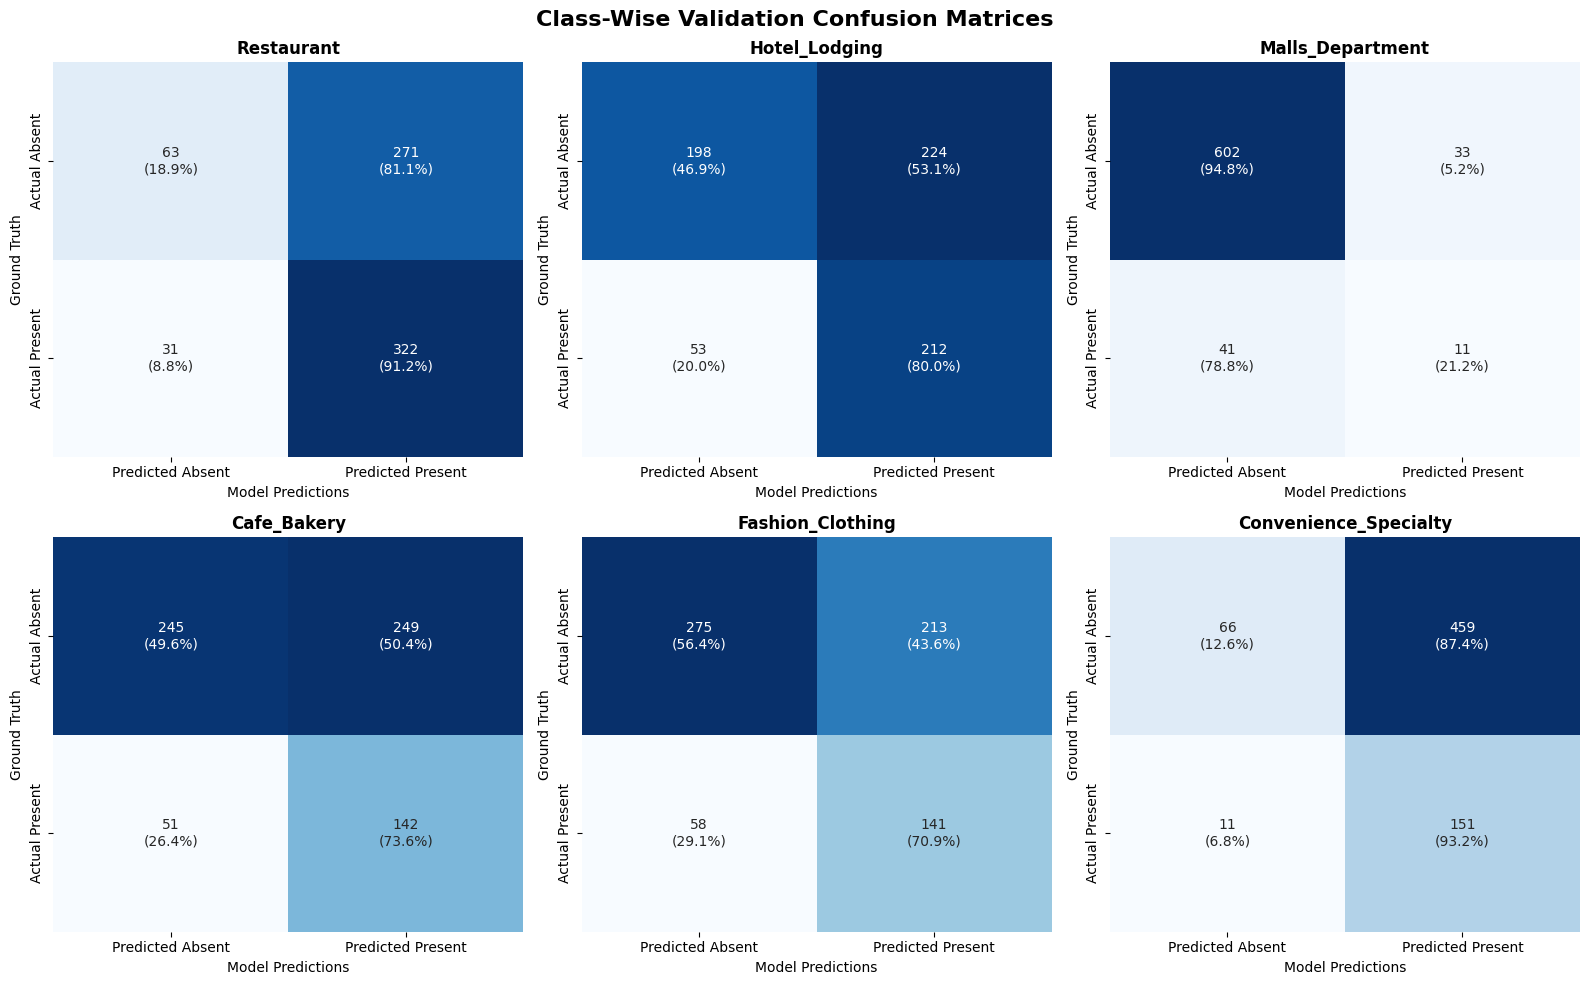

🚀 Training MLPClassifier Multi-Label Architecture...
🎯 Calculating optimal decision thresholds per class...

Optimal Thresholds for Heatmaps:
 - Restaurant: 0.365
 - Hotel_Lodging: 0.414
 - Malls_Department: 0.133
 - Cafe_Bakery: 0.349
 - Fashion_Clothing: 0.234
 - Convenience_Specialty: 0.200

📊 GLOBAL MULTI-LABEL PERFORMANCE METRICS MLPClassifier
Overall Exact Match Ratio (Subset Accuracy): 0.1106
Macro F1-Score Baseline:                     0.4932
Global Hamming Loss Threshold:              0.3588
------------------------------------------------------------

🔍 CLASS-WISE VALIDATION EVALUATIONS:
                       Accuracy  F1-Score  Precision  Recall
Commercial Class                                            
Restaurant               0.5473    0.6817     0.5337  0.9433
Hotel_Lodging            0.6536    0.6073     0.5396  0.6943
Malls_Department         0.8282    0.2237     0.1700  0.3269
Cafe_Bakery              0.7045    0.5268     0.4788  0.5855
Fashion_Clothing         0.59

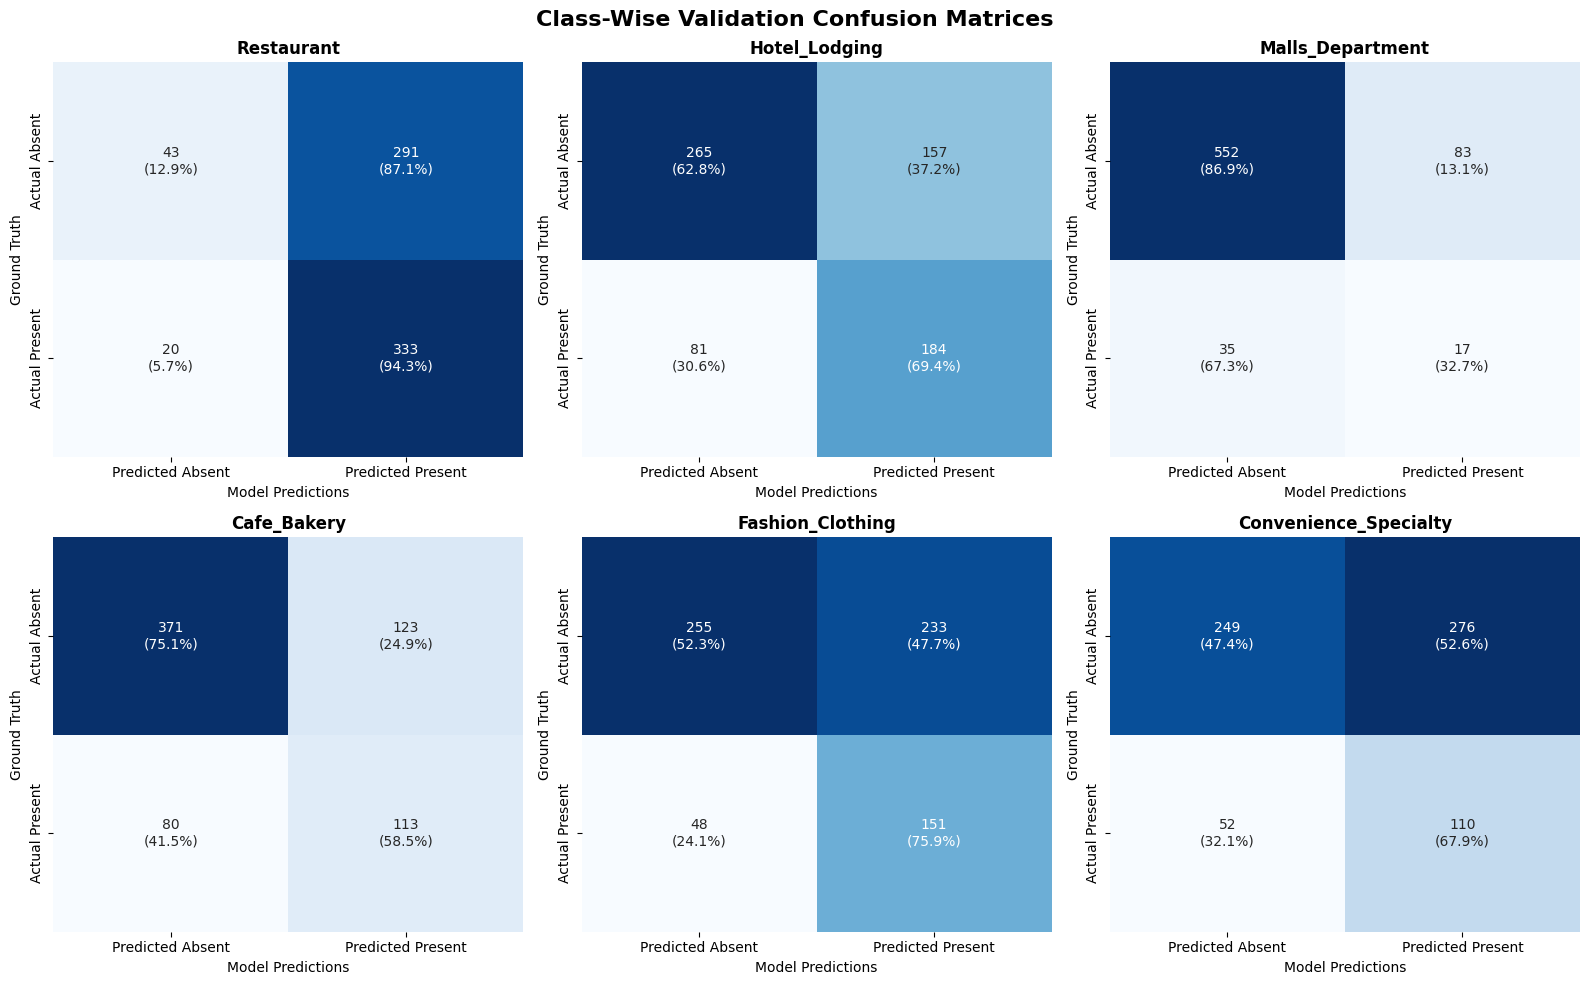

🚀 Training XGBoost Multi-Label Architecture...
🎯 Calculating optimal decision thresholds per class...

Optimal Thresholds for Heatmaps:
 - Restaurant: 0.065
 - Hotel_Lodging: 0.231
 - Malls_Department: 0.107
 - Cafe_Bakery: 0.114
 - Fashion_Clothing: 0.188
 - Convenience_Specialty: 0.073

📊 GLOBAL MULTI-LABEL PERFORMANCE METRICS XGBoost
Overall Exact Match Ratio (Subset Accuracy): 0.0611
Macro F1-Score Baseline:                     0.4895
Global Hamming Loss Threshold:              0.3729
------------------------------------------------------------

🔍 CLASS-WISE VALIDATION EVALUATIONS:
                       Accuracy  F1-Score  Precision  Recall
Commercial Class                                            
Restaurant               0.5328    0.6837     0.5242  0.9830
Hotel_Lodging            0.6332    0.6111     0.5170  0.7472
Malls_Department         0.8908    0.2424     0.2553  0.2308
Cafe_Bakery              0.5429    0.4836     0.3542  0.7617
Fashion_Clothing         0.6783    0.5143

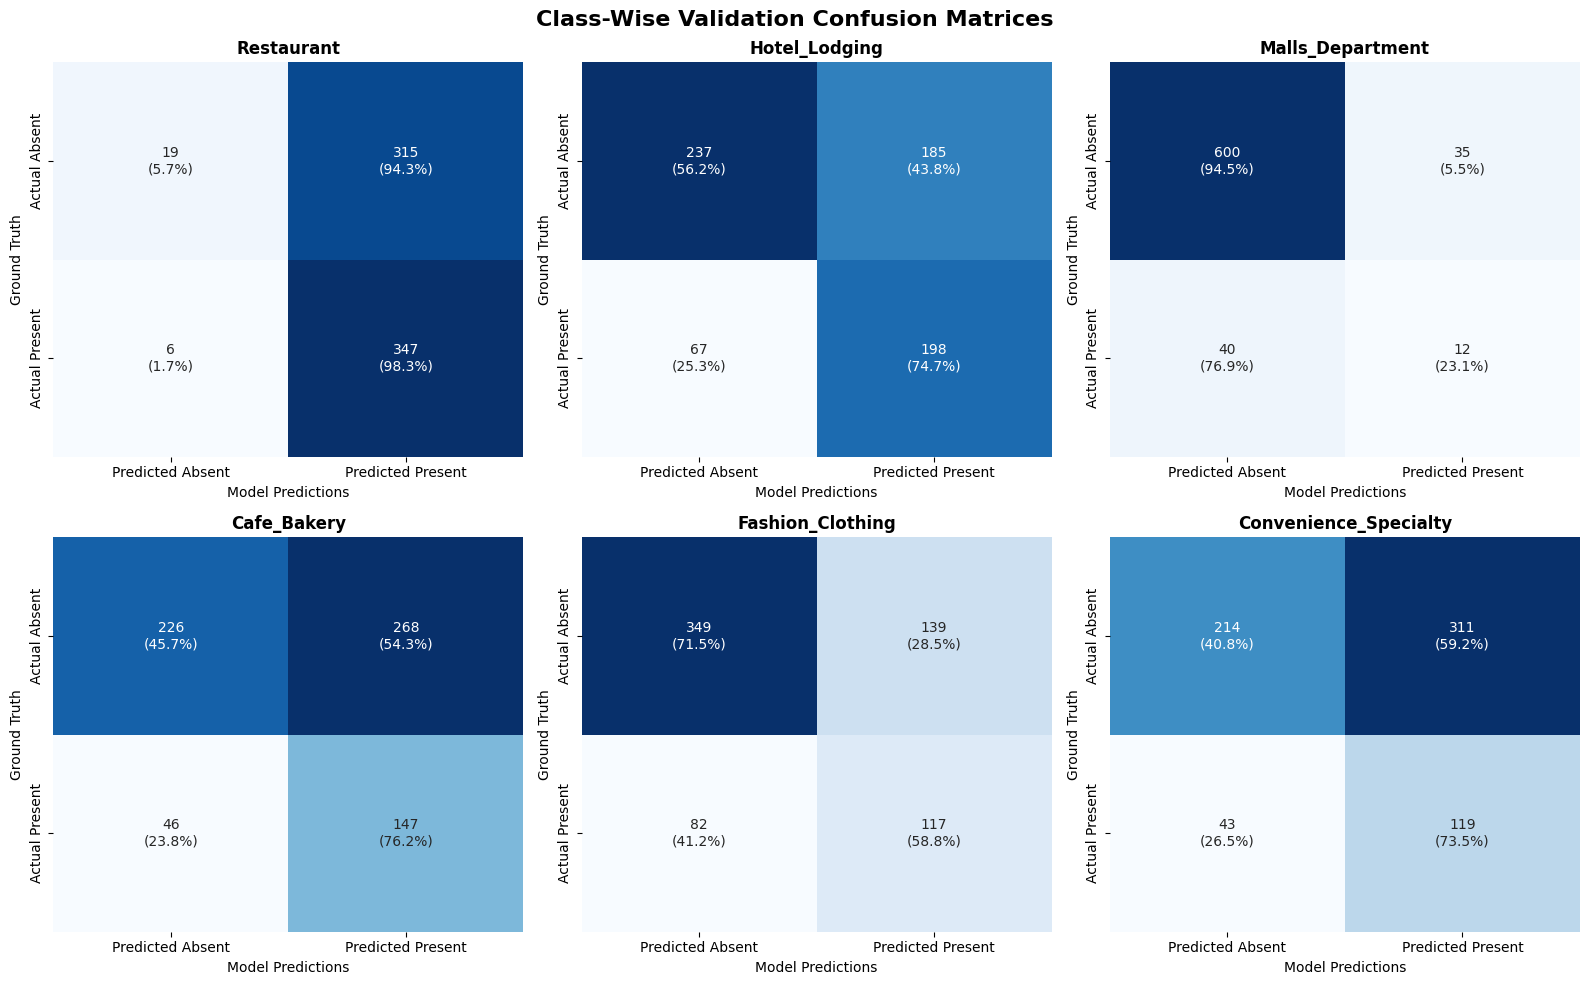

In [7]:
DATA_DIR=Path(r"C:\Users\anils\Desktop\7th SEM\GIS\GeoOptim\Data\Final\MultiLabel_DATA_V2.geojson")
train_model(DATA_DIR, MODEL)

In [12]:
# Modular

import joblib
import geopandas as gpd
import numpy as np
import pandas as pd
from pathlib import Path

BASE_DIR = Path(r"C:\Users\anils\Desktop\7th SEM\GIS\GeoOptim\Output")

def infer(model_path, scaler_path, data_path, output_path, single=False):
    print("⏳ Loading model pipeline artifacts...")
    scaler = joblib.load(scaler_path)
    model = joblib.load(model_path)

    hex_gdf = gpd.read_file(data_path)
    # Define the non-feature tracking attributes to isolate your dynamic feature matrix
    metadata_cols = ['h3_id', 'geometry']
    feature_cols = [col for col in hex_gdf.columns if col not in metadata_cols and not col.startswith('prob_')]

    # The target multi-label classes your network yields output arrays for
    clean_label_names = [
        'Restaurant', 'Hotel_Lodging', 'Malls_Department', 'Cafe_Bakery' 
        , 'Fashion_Clothing', 'Convenience_Specialty'
    ]

    X_inference = hex_gdf[feature_cols].copy()
    # Ensure feature counts align with what the scaler expects
    expected_features = scaler.n_features_in_
    actual_features = len(feature_cols)
    if actual_features != expected_features:
        raise ValueError(f"❌ Feature count mismatch! Model expects {expected_features}, but dataset has {actual_features}.")

    # ==============================================================================
    # 4. Run Scaling and Predict Probabilities (FIXED FOR MLP)
    # ==============================================================================
    print("⚖️ Normalizing features using loaded RobustScaler...")
    X_inference_scaled = scaler.transform(X_inference)
    print("🧠 Running Multi-Label MLP model inference engine...")
    # ✨ FIX: For MLP Multi-label, y_prob is a single 2D array of shape (n_samples, n_classes)
    y_prob_matrix = model.predict_proba(X_inference_scaled)

    if single:
        y_prob_matrix = np.column_stack([prob[:, 1] for prob in y_prob_matrix])

    print("📈 Appending class probabilities to dataset...")
    for idx, label_name in enumerate(clean_label_names):
        # Slice the matrix column directly for each target class
        hex_gdf[f'prob_{label_name}'] = y_prob_matrix[:, idx].astype('float32')

    # ==============================================================================
    # 5. Export Updated Geographic Layer File
    # ==============================================================================
    print(f"💾 Saving complete prediction probability field matrix...")
    hex_gdf.to_file(output_path, driver="GeoJSON")

    print("\n🎉 Model Inference Run Complete!")
    print(f"Saved completed predictions with {len(clean_label_names)} probability fields")

In [15]:
model_path = BASE_DIR/r"Models/xgb_multilabel_model.pkl"
scaler_path = BASE_DIR/r"Models/robust_scaler.pkl"
data_path = r"C:\Users\anils\Desktop\7th SEM\GIS\GeoOptim\Data\Final\hexagon_ktm_V2.geojson"
output_path = BASE_DIR/r"Plots\xgb_prediction.geojson"
infer(model_path, scaler_path, data_path, output_path, single=True)

⏳ Loading model pipeline artifacts...
⚖️ Normalizing features using loaded RobustScaler...
🧠 Running Multi-Label MLP model inference engine...
📈 Appending class probabilities to dataset...
💾 Saving complete prediction probability field matrix...

🎉 Model Inference Run Complete!
Saved completed predictions with 6 probability fields
